## Exploring the Geography of Crime: A Data-Driven Study of Los Angeles

Group 40: Milo Leach, Harshini Dinesh, Samuel Castelein

Understanding how crime is distributed across Los Angeles is essential for identifying patterns that can inform public safety strategies, law enforcement resource allocation, and community awareness efforts. Los Angeles is a large and diverse city, with varying socioeconomic, demographic, and geographic characteristics that may influence the frequency and type of crimes occurring in different areas. By analyzing the distribution of crimes — such as theft, burglary, identity theft, and assault — we can uncover whether certain neighborhoods or population groups are more vulnerable to specific types of crime. This analysis can help policymakers and local authorities develop targeted interventions to reduce crime rates, improve safety, and promote equity in public protection across the city.


Link to Dataset: https://catalog.data.gov/dataset/crime-data-from-2020-to-present


Dataset Column Info: https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data

In [1]:
#replacement cols
clean_columns = [
    'dr_no',             # DR_NO
    'date_rptd',         # Date Rptd
    'date_occ',          # DATE OCC
    'time_occ',          # TIME OCC
    'area',              # AREA
    'area_name',         # AREA NAME
    'rpt_dist_no',       # Rpt Dist No
    'part_1_2',          # Part 1-2
    'crm_cd',            # Crm Cd
    'crm_cd_desc',       # Crm Cd Desc
    'mocodes',           # Mocodes
    'vict_age',          # Vict Age
    'vict_sex',          # Vict Sex
    'vict_descent',      # Vict Descent
    'premis_cd',         # Premis Cd
    'premis_desc',       # Premis Desc
    'weapon_used_cd',    # Weapon Used Cd
    'weapon_desc',       # Weapon Desc
    'status',            # Status
    'status_desc',       # Status Desc
    'crm_cd_1',          # Crm Cd 1
    'crm_cd_2',          # Crm Cd 2
    'crm_cd_3',          # Crm Cd 3
    'crm_cd_4',          # Crm Cd 4
    'location',          # LOCATION
    'cross_street',      # Cross Street
    'lat',               # LAT
    'lon'                # LON
]

In [2]:
import pandas as pd
df = pd.read_csv('data/Crime_Data_from_2020_to_Present.csv')
#replace column names with column names that are easier to use and more consistent
df.columns = clean_columns

#clean up df
#drop entries that were recorded twice
df.drop_duplicates(subset=[col for col in df.columns if col != 'dr_no'], inplace=True)

#useless or redundant
df.drop(['part_1_2', 'crm_cd_1'], axis =1, inplace=True)

#drop crimes with missing crime type
df.dropna(subset = ['crm_cd'], inplace=True)

#convert dates to datetime
df['date_occ'] = pd.to_datetime(df['date_occ'], errors='coerce')
df['date_rptd'] = pd.to_datetime(df['date_rptd'], errors='coerce')

#convert time occured to an actual time
df['time_occ'] = pd.to_datetime((df['time_occ'] // 100 ).astype('string') + ':' + (df['time_occ'] % 100 ).astype('string'), format="%H:%M")

#drop nonsensical values
df = df.loc[(df.vict_age > 0) & (df.date_rptd > df.date_occ)]

C:\Users\milol\AppData\Local\Temp\ipykernel_16512\3664478493.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_occ'] = pd.to_datetime(df['date_occ'], errors='coerce')
C:\Users\milol\AppData\Local\Temp\ipykernel_16512\3664478493.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_rptd'] = pd.to_datetime(df['date_rptd'], errors='coerce')


In [3]:
df.head()


,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,crm_cd,crm_cd_desc,mocodes,...,weapon_desc,status,status_desc,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
0,211507896,2021-04-11,2020-11-07,1900-01-01 08:45:00,15,N Hollywood,1502,354,THEFT OF IDENTITY,0377,...,NaN,IC,Invest Cont,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,2020-10-21,2020-10-18,1900-01-01 18:45:00,15,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,...,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,2024-12-10,2020-10-30,1900-01-01 12:40:00,9,Van Nuys,933,354,THEFT OF IDENTITY,0377,...,NaN,IC,Invest Cont,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
4,201418201,2020-10-03,2020-09-29,1900-01-01 18:30:00,14,Pacific,1454,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,...,NaN,IC,Invest Cont,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350
5,240412063,2024-12-11,2020-11-11,1900-01-01 12:10:00,4,Hollenbeck,429,354,THEFT OF IDENTITY,0100,...,NaN,IC,Invest Cont,NaN,NaN,NaN,5300 CRONUS ST,NaN,34.0830,-118.1678


### Make Example Viz (2)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
#make map for crime codes/descriptions
code_map = {}
unique_codes = df.drop_duplicates(subset = ['crm_cd'], keep='first')[['crm_cd', 'crm_cd_desc']].set_index('crm_cd')

code_map = unique_codes.crm_cd_desc.to_dict()

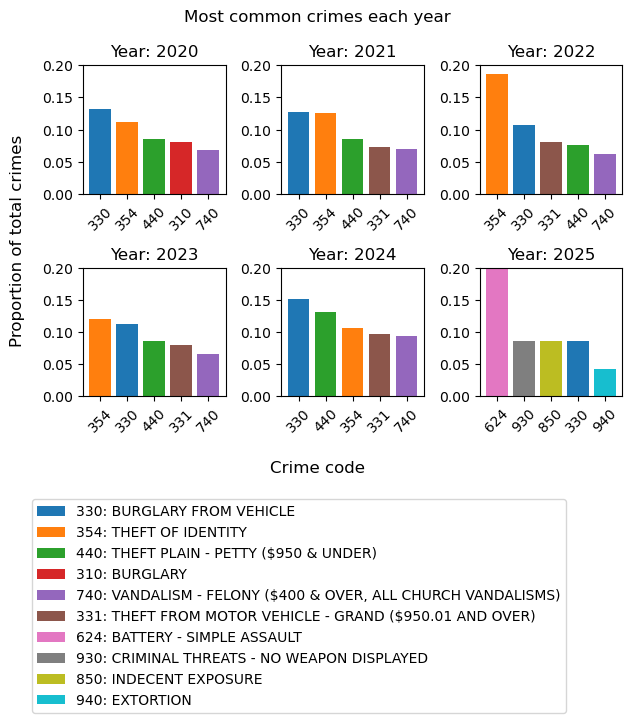

In [6]:
from matplotlib.patches import Patch
'''
Plots bar graphs to see most common crimes from 2020 to 2025.
'''

# gets total number of each crime for each year
years = pd.crosstab(df.date_occ.dt.year, df.crm_cd).reset_index()
transformed = years.melt(id_vars='date_occ', var_name='crm_cd', value_name='count')
totals = transformed.groupby('date_occ')['count'].sum()

# picks the 5 most common for each year and finds out what percent of the total they were for that year
idx=[]
for year in transformed.date_occ.unique():
    temp = transformed.loc[transformed.date_occ == year]
    idx += (temp.sort_values('count', ascending=False)[:5].index.tolist())
for_plotting = transformed.iloc[idx].reset_index(drop=True)
for_plotting['count'] = for_plotting['count'] / for_plotting['date_occ'].map(totals)

#makes a colormap for better plotting
unique_codes = for_plotting.crm_cd.unique()
colors = plt.get_cmap('tab10', len(unique_codes)) 
color_map = dict(zip(unique_codes, colors.colors))

# plots
fig, ax = plt.subplots(2, 3)
row = col = 0

# makes barplots
for y in range(2020, 2026):
    data = for_plotting.loc[for_plotting.date_occ == y]
    ax[row, col].bar(data.crm_cd.astype(str), data['count'], color=[color_map[x] for x in data.crm_cd])
    ax[row, col].set_title(f'Year: {y}')
    ax[row, col].tick_params(axis='x', labelrotation=45)
    #make sure all plots have the same scale
    ax[row, col].set_ylim(0, 0.2)
    
    col+=1
    if col>2:
        row+=1
        col=0
# if col<=3 and row <=2:
#     fig.delaxes(ax[1, 2])
fig.supxlabel('Crime code')
fig.supylabel('Proportion of total crimes')
#custom legend that shows colors and 
fig.legend(handles=[Patch(facecolor=color_map[code], label='{0}: {1}'.format(code, code_map[code])) for code in unique_codes], 
           loc='lower right',
           bbox_to_anchor=(0.9, -0.5))
fig.suptitle('Most common crimes each year')
fig.tight_layout()
fig.savefig('crime_dist')

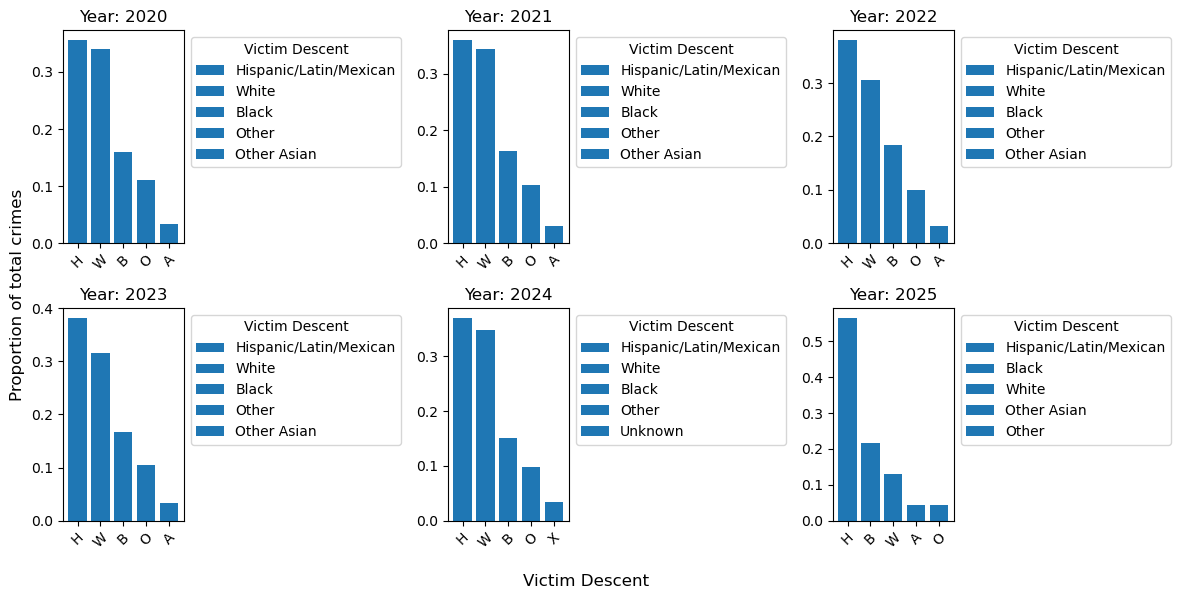

In [7]:
'''
Plots bar graphs to see if certain demographics (races) are targeted by crime more than others, 
which shows total crimes perpetrated against each subgroup from 2020 to 2025.
'''
# aggregates counts by year and victim descent
years = df.groupby([df.date_occ.dt.year, 'vict_descent']).size().reset_index(name='count')

# keeps the top 5 victim descent groups per year
top_idx = []
for year in years['date_occ'].unique():
    top_idx += years[years['date_occ'] == year].sort_values('count', ascending=False).head(5).index.tolist()

for_plotting = years.loc[top_idx].copy()

# calculates proportions within each year
for_plotting['proportion'] = for_plotting['count'] / for_plotting.groupby('date_occ')['count'].transform('sum')

# maps codes to labels for different races
descent_map = {
    "A": "Other Asian",
    "B": "Black",
    "C": "Chinese",
    "D": "Cambodian",
    "F": "Filipino",
    "G": "Guamanian",
    "H": "Hispanic/Latin/Mexican",
    "I": "American Indian/Alaskan Native",
    "J": "Japanese",
    "K": "Korean",
    "L": "Laotian",
    "O": "Other",
    "P": "Pacific Islander",
    "S": "Samoan",
    "U": "Hawaiian",
    "V": "Vietnamese",
    "W": "White",
    "X": "Unknown",
    "Z": "Asian Indian"
}


# plots bar graphs
fig, ax = plt.subplots(2, 3, figsize=(12,6))
row = col = 0
for y in range(2020, 2026):
    data = for_plotting[for_plotting['date_occ'] == y]
    if data.empty:
        continue
    bars = ax[row, col].bar(data['vict_descent'], data['proportion'])
    ax[row, col].set_title(f'Year: {y}')
    ax[row, col].tick_params(axis='x', rotation=45)

     # uses mapping to add legend to each subplot
     # places legend outside the axes (to the right of the plots)
    ax[row, col].legend(
        bars, 
        [descent_map.get(code, code) for code in data['vict_descent']], 
        title='Victim Descent',
        loc='upper left',       
        bbox_to_anchor=(1, 1)  
    )
    
    col += 1
    if col > 2:
        row += 1
        col = 0

fig.supxlabel('Victim Descent')
fig.supylabel('Proportion of total crimes')
fig.tight_layout()
plt.show()

### Map

In [10]:
import geopandas as gpd
import altair as alt
df.head()

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,crm_cd,crm_cd_desc,mocodes,...,weapon_desc,status,status_desc,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
0,211507896,2021-04-11,2020-11-07,1900-01-01 08:45:00,15,N Hollywood,1502,354,THEFT OF IDENTITY,0377,...,NaN,IC,Invest Cont,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,2020-10-21,2020-10-18,1900-01-01 18:45:00,15,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,...,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,2024-12-10,2020-10-30,1900-01-01 12:40:00,9,Van Nuys,933,354,THEFT OF IDENTITY,0377,...,NaN,IC,Invest Cont,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
4,201418201,2020-10-03,2020-09-29,1900-01-01 18:30:00,14,Pacific,1454,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,...,NaN,IC,Invest Cont,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350
5,240412063,2024-12-11,2020-11-11,1900-01-01 12:10:00,4,Hollenbeck,429,354,THEFT OF IDENTITY,0100,...,NaN,IC,Invest Cont,NaN,NaN,NaN,5300 CRONUS ST,NaN,34.0830,-118.1678


In [20]:
reptd_1 = gpd.read_file('data/LAPD_Reporting_District.zip')
reptd_1.head()

,OBJECTID,AGENCY,ST_NAME,S_TYPE,BUREAU,APREC,ABBREV_APR,PREC,REPDIST,NAME,...,BASICCAR,p1_db_DBO_,PERIMETER,SHAPE_LENG,Shape_Le_1,Shape_Area,Shape__Are,Shape__Len,Area_in_sq,geometry
0,1,OT,ROLLING HILLS,Sheriff,None,None,None,0,0,9RH,...,None,85096190.0,48250.18,0.145549,0.145549,0.000769,1.146587e+07,17712.608014,7904613,"POLYGON ((-13173784.239 3998666.5, -13173636.5..."
1,2,OT,L.A. COUNTY,Sheriff,None,None,None,0,0,9LAC,...,None,14709890.0,18351.60,0.055334,2.103775,0.009044,1.351102e+08,258233.080515,92729475,"MULTIPOLYGON (((-13194383.939 4071812.094, -13..."
2,3,OT,ROLLING HILLS ESTATES,Sheriff,None,None,None,0,0,9RHE,...,None,100312500.0,116144.50,0.352494,0.352494,0.000907,1.352197e+07,42638.201290,9318115,"POLYGON ((-13174787.878 4001303.909, -13174595..."
3,4,OT,PALOS VERDES ESTATES,Sheriff,None,None,None,0,0,9PVE,...,None,133331500.0,70950.24,0.219689,0.219689,0.001206,1.797671e+07,26035.871176,12385376,"POLYGON ((-13175965.544 4002531.425, -13175253..."
4,5,OT,HERMOSA BEACH,Sheriff,None,None,None,0,0,9HMB,...,None,41007140.0,28836.17,0.085685,0.085685,0.000371,5.539158e+06,10603.110454,3809399,"POLYGON ((-13180769.42 4012408.084, -13180751...."


In [18]:
reptd_2= gpd.read_file('data/Law_Enforcement_Reporting_Districts.zip')
reptd_2.head()

,OBJECTID,RD,S_TYPE,COMMTYPE,NAME,ST_NAME,OMEGA_LABE,LABEL,AGENCY,STATION,OMEGA_NAME,Shape_Leng,Shape_Area,geometry
0,1,None,Police,City,Whittier,Whittier,Whittier,Whittier Police,OTHER,None,OTHER WHITTIER,46391.910817,5.552949e+07,"POLYGON ((-13136447.302 4026690.587, -13136450..."
1,2,????,Police,City,Monrovia,Monrovia,Monrovia ????,Monrovia Police,OTHER,None,OTHER MONROVIA ????,47912.837217,1.138253e+08,"POLYGON ((-13129823.691 4051009.158, -13129944..."
2,3,????,Police,City,Monterey Park,Monterey Park,Monterey Park ????,Monterey Park Police,OTHER,None,OTHER MONTEREY PARK ????,1317.146150,8.413453e+04,"POLYGON ((-13149647.342 4037197.214, -13149669..."
3,4,001,Police,City,Burbank,Burbank,Burbank 001,Burbank Police,OTHER,None,OTHER BURBANK 001,20867.218465,1.651578e+07,"POLYGON ((-13172048.118 4057263.753, -13172059..."
4,5,001,Police,City,Covina,Covina,Covina 001,Covina Police,OTHER,None,OTHER COVINA 001,95190.227544,6.971128e+07,"MULTIPOLYGON (((-13118608.956 4041673.671, -13..."


(<Axes: title={'center': 'v1'}>, <Axes: title={'center': 'v2'}>)

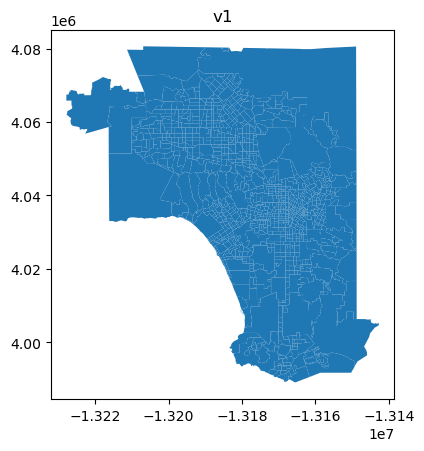

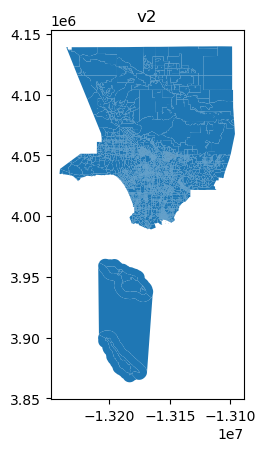

In [25]:
fig1 = reptd_1.plot()
fig1.set_title("v1")
fig2 = reptd_2.plot()
fig2.set_title("v2")

fig1, fig2